In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification
import os

DATA_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task"
MODEL_PATH = "/kaggle/input/datasets/hadilboo/my-vit-base-weights"

TRAIN_PATH = os.path.join(DATA_DIR, "train")
TEST_PATH = os.path.join(DATA_DIR, "test")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Classes détectées : {train_dataset.classes}")

print("Chargement du modèle ViT en mode Offline...")

model = ViTForImageClassification.from_pretrained(
    MODEL_PATH, 
    num_labels=4, 
    ignore_mismatched_sizes=True,  #remplacer la couche de 1000 classes par 4 classes
    local_files_only=True
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
epochs = 5 

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    print(f"Époque [{epoch+1}/{epochs}] | Loss: {running_loss/len(train_loader):.4f} | Acc: {100.*correct/total:.2f}%")

model.eval()
test_correct = 0
test_total = 0

print("\nÉvaluation finale...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        logits = outputs.logits
        _, predicted = logits.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"Précision sur le Test Set : {100. * test_correct / test_total:.2f}%")

Classes détectées : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Chargement du modèle ViT en mode Offline...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: /kaggle/input/datasets/hadilboo/my-vit-base-weights
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Époque [1/5] | Loss: 0.4821 | Acc: 84.74%
Époque [2/5] | Loss: 0.0893 | Acc: 97.78%
Époque [3/5] | Loss: 0.0259 | Acc: 99.58%
Époque [4/5] | Loss: 0.0104 | Acc: 99.88%
Époque [5/5] | Loss: 0.0048 | Acc: 100.00%

Évaluation finale...
Précision sur le Test Set : 98.30%


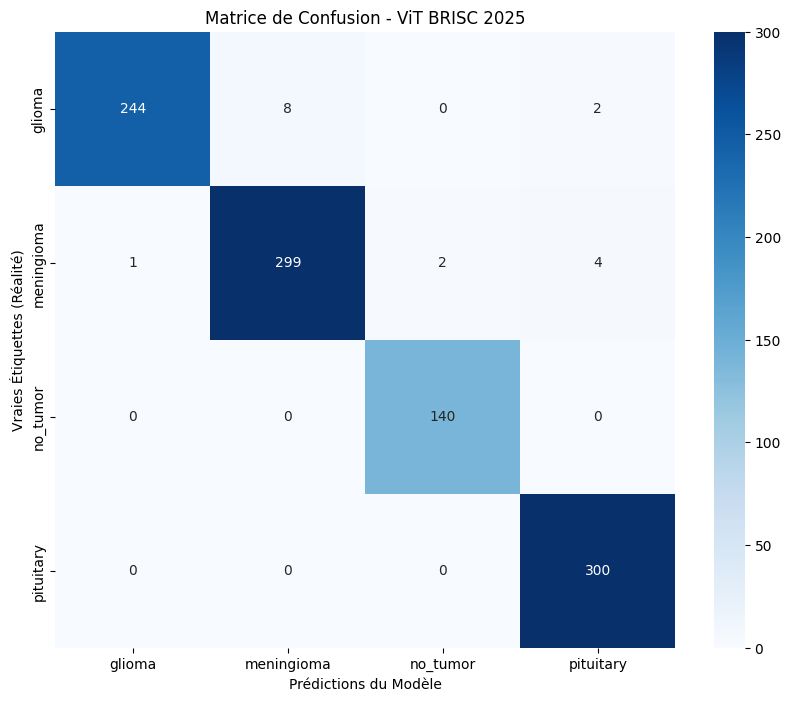


Rapport de Classification détaillé :
              precision    recall  f1-score   support

      glioma       1.00      0.96      0.98       254
  meningioma       0.97      0.98      0.98       306
    no_tumor       0.99      1.00      0.99       140
   pituitary       0.98      1.00      0.99       300

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        logits = outputs.logits
        _, predicted = torch.max(logits, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
classes = train_dataset.classes  

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Vraies Étiquettes (Réalité)')
plt.title('Matrice de Confusion - ViT BRISC 2025')
plt.show()

print("\nRapport de Classification détaillé :")
print(classification_report(all_labels, all_preds, target_names=classes))